# Deepfake Detection Model

## Training on 140k Real and Fake Faces Dataset

This notebook trains a state-of-the-art deepfake detection model using:
- **ConvNeXt Large** 
- **Advanced augmentation** (MixUp, CutMix, Multi-scale)
- **Focal Loss** for class imbalance
- **MTCNN** for high-quality face detection
- **Optimized for Kaggle GPU**

**Dataset**: 140k Real and Fake Faces  


In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import numpy as np
from pathlib import Path
import os
from tqdm import tqdm
import gc
import timm
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Configuration - OPTIMIZED FOR SPEED & ANTI-OVERFITTING
CONFIG = {
    'image_size': 224,
    'batch_size': 64,  # Large batch for speed
    'num_epochs': 50,
    'learning_rate': 5e-5,  # Lower LR to prevent overfitting
    'weight_decay': 2e-4,  # Higher weight decay for regularization
    'num_workers': 8,  # More workers for speed
    'device': 'cuda' if torch.cuda.is_available() else 'cpu',
    
    'model_name': 'efficientnet_b4',  # EfficientNet-B4
    
    # Dataset paths (140k Real and Fake Faces)
    'data_root': '/kaggle/input/140k-real-and-fake-faces',
    'train_path': '/kaggle/input/140k-real-and-fake-faces/real_vs_fake/real-vs-fake/train',
    'valid_path': '/kaggle/input/140k-real-and-fake-faces/real_vs_fake/real-vs-fake/valid',
    'test_path': '/kaggle/input/140k-real-and-fake-faces/real_vs_fake/real-vs-fake/test',
    
    'save_path': '/kaggle/working/best_deepfake_model.pth',
    
    # NO FACE DETECTION - Dataset is pre-cropped!
    'use_face_crop': False,
    
    # Augmentation (disabled for speed, minimal for anti-overfitting)
    'use_mixup': False,
    'use_cutmix': False,
    'label_smoothing': 0.15,  # Higher for generalization
    'use_focal_loss': True,
    'focal_alpha': 0.25,
    'focal_gamma': 2.0,
    
    # Early Stopping
    'early_stopping_patience': 7,
    'early_stopping_min_delta': 0.0001,
    
    # Gradient Accumulation (if needed for memory)
    'gradient_accumulation_steps': 1,
}

print(f"✅ Device: {CONFIG['device']}")
print(f"✅ Model: {CONFIG['model_name']} (EfficientNet-B4)")
print(f"✅ Face Detection: DISABLED (pre-cropped dataset)")
print(f"✅ Batch Size: {CONFIG['batch_size']}")
print(f"✅ Workers: {CONFIG['num_workers']}")

/usr/local/lib/python3.11/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'frozen' attribute with value True was provided to the `Field()` function, which has no effect in the context it was used. 'frozen' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` 

✅ Device: cuda
✅ Model: efficientnet_b4 (EfficientNet-B4)
✅ Face Detection: DISABLED (pre-cropped dataset)
✅ Batch Size: 64
✅ Workers: 8


In [2]:
class FocalLoss(nn.Module):
    def __init__(self, alpha=0.25, gamma=2.0, reduction='mean'):
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction
    
    def forward(self, inputs, targets):
        ce_loss = nn.functional.cross_entropy(inputs, targets, reduction='none')
        pt = torch.exp(-ce_loss)
        focal_loss = self.alpha * (1 - pt) ** self.gamma * ce_loss
        
        if self.reduction == 'mean':
            return focal_loss.mean()
        elif self.reduction == 'sum':
            return focal_loss.sum()
        return focal_loss

class LabelSmoothingCrossEntropy(nn.Module):
    def __init__(self, smoothing=0.1):
        super(LabelSmoothingCrossEntropy, self).__init__()
        self.smoothing = smoothing
    
    def forward(self, pred, target):
        log_prob = nn.functional.log_softmax(pred, dim=1)
        nll_loss = -log_prob.gather(dim=1, index=target.unsqueeze(1)).squeeze(1)
        smooth_loss = -log_prob.mean(dim=1)
        loss = (1 - self.smoothing) * nll_loss + self.smoothing * smooth_loss
        return loss.mean()

In [3]:
class DeepfakeDataset(Dataset):
    def __init__(self, data_dir, transform=None):
        self.data_dir = Path(data_dir)
        self.transform = transform
        
        real_dir = self.data_dir / 'real'
        fake_dir = self.data_dir / 'fake'
        
        self.image_paths = []
        self.labels = []
        
        if real_dir.exists():
            real_images = (list(real_dir.glob('*.jpg')) + 
                          list(real_dir.glob('*.png')) + 
                          list(real_dir.glob('*.jpeg')) + 
                          list(real_dir.glob('*.JPG')))
            self.image_paths.extend(real_images)
            self.labels.extend([0] * len(real_images))
        
        if fake_dir.exists():
            fake_images = (list(fake_dir.glob('*.jpg')) + 
                          list(fake_dir.glob('*.png')) + 
                          list(fake_dir.glob('*.jpeg')) + 
                          list(fake_dir.glob('*.JPG')))
            self.image_paths.extend(fake_images)
            self.labels.extend([1] * len(fake_images))
        
        if len(self.image_paths) == 0:
            raise ValueError(f"No images found in {data_dir}")
        
        print(f"   Loaded {len(self.image_paths):,} images from {self.data_dir.name}")
        print(f"      Real: {sum(1 for l in self.labels if l == 0):,}")
        print(f"      Fake: {sum(1 for l in self.labels if l == 1):,}")
    
    def __len__(self):
        return len(self.image_paths)
    
    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        label = self.labels[idx]
        
        try:
            image = Image.open(img_path).convert('RGB')
        except Exception as e:
            # Fallback for corrupted images
            image = Image.new('RGB', (224, 224), (128, 128, 128))
        
        if self.transform:
            image = self.transform(image)
        
        label = torch.tensor(label, dtype=torch.long)
        return image, label

In [4]:
# Train transforms - Minimal augmentation for speed
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# Validation/Test transforms - No augmentation
val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

In [5]:
print("Loading datasets...")
train_dataset = DeepfakeDataset(CONFIG['train_path'], transform=train_transform)
valid_dataset = DeepfakeDataset(CONFIG['valid_path'], transform=val_transform)
test_dataset = DeepfakeDataset(CONFIG['test_path'], transform=val_transform)

train_loader = DataLoader(
    train_dataset, 
    batch_size=CONFIG['batch_size'], 
    shuffle=True, 
    num_workers=CONFIG['num_workers'],
    pin_memory=False,
    persistent_workers=True if CONFIG['num_workers'] > 0 else False,
    drop_last=True
)

valid_loader = DataLoader(
    valid_dataset, 
    batch_size=CONFIG['batch_size'], 
    shuffle=False, 
    num_workers=CONFIG['num_workers'],
    pin_memory=False,
    persistent_workers=True if CONFIG['num_workers'] > 0 else False
)

test_loader = DataLoader(
    test_dataset, 
    batch_size=CONFIG['batch_size'], 
    shuffle=False, 
    num_workers=CONFIG['num_workers'],
    pin_memory=False,
    persistent_workers=True if CONFIG['num_workers'] > 0 else False
)

print(f"\n✅ Train batches: {len(train_loader)}")
print(f"✅ Valid batches: {len(valid_loader)}")
print(f"✅ Test batches: {len(test_loader)}")

Loading datasets...
   Loaded 100,000 images from train
      Real: 50,000
      Fake: 50,000
   Loaded 20,000 images from valid
      Real: 10,000
      Fake: 10,000
   Loaded 20,000 images from test
      Real: 10,000
      Fake: 10,000

✅ Train batches: 1562
✅ Valid batches: 313
✅ Test batches: 313


/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py:624: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 4, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


In [6]:
torch.cuda.empty_cache()
gc.collect()

print(f"Creating {CONFIG['model_name']} model...")
model = timm.create_model(
    CONFIG['model_name'],
    pretrained=True,
    num_classes=2,
    drop_rate=0.3,  # Higher dropout for anti-overfitting
    drop_path_rate=0.3,
)

# Enable gradient checkpointing for memory efficiency
if hasattr(model, 'set_grad_checkpointing'):
    model.set_grad_checkpointing(True)

model = model.to(CONFIG['device'])
print(f"✅ Model created: {sum(p.numel() for p in model.parameters()):,} parameters")

Creating efficientnet_b4 model...


model.safetensors:   0%|          | 0.00/77.9M [00:00<?, ?B/s]

✅ Model created: 17,552,202 parameters


In [7]:
if CONFIG['use_focal_loss']:
    criterion = FocalLoss(
        alpha=CONFIG['focal_alpha'],
        gamma=CONFIG['focal_gamma']
    )
    print("✅ Using Focal Loss")
elif CONFIG['label_smoothing'] > 0:
    criterion = LabelSmoothingCrossEntropy(smoothing=CONFIG['label_smoothing'])
    print(f"✅ Using Label Smoothing (smoothing={CONFIG['label_smoothing']})")
else:
    criterion = nn.CrossEntropyLoss()
    print("✅ Using CrossEntropy Loss")

✅ Using Focal Loss


In [8]:
optimizer = optim.AdamW(
    model.parameters(),
    lr=CONFIG['learning_rate'],
    weight_decay=CONFIG['weight_decay']
)

# ReduceLROnPlateau for anti-overfitting
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, 
    mode='min', 
    factor=0.5, 
    patience=3, 
    verbose=True,
    min_lr=1e-7
)

print("✅ Optimizer: AdamW")
print("✅ Scheduler: ReduceLROnPlateau")

✅ Optimizer: AdamW
✅ Scheduler: ReduceLROnPlateau


/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


In [10]:
def train_epoch_advanced(model, loader, criterion, optimizer, device, epoch):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    pbar = tqdm(loader, desc=f"Epoch {epoch} [Train]")
    
    optimizer.zero_grad()
    
    for batch_idx, (images, labels) in enumerate(pbar):
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)
        
        # Forward pass
        outputs = model(images)
        loss = criterion(outputs, labels)
        
        # Scale loss for gradient accumulation
        loss = loss / CONFIG['gradient_accumulation_steps']
        loss.backward()
        
        # Gradient accumulation
        if (batch_idx + 1) % CONFIG['gradient_accumulation_steps'] == 0:
            # Gradient clipping for stability
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            optimizer.zero_grad()
        
        # Metrics
        running_loss += loss.item() * CONFIG['gradient_accumulation_steps']
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
        
        # Update progress bar
        pbar.set_postfix({
            'loss': f"{running_loss/(batch_idx+1):.4f}",
            'acc': f"{100.*correct/total:.2f}%",
            'lr': f"{optimizer.param_groups[0]['lr']:.2e}"
        })
    
    epoch_loss = running_loss / len(loader)
    epoch_acc = 100. * correct / total
    
    return epoch_loss, epoch_acc

def validate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    all_preds = []
    all_labels = []
    all_probs = []
    
    with torch.no_grad():
        for images, labels in tqdm(loader, desc="Validating"):
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)
            
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            running_loss += loss.item()
            probs = torch.softmax(outputs, dim=1)
            _, preds = outputs.max(1)
            
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs[:, 1].cpu().numpy())
    
    loss = running_loss / len(loader)
    acc = accuracy_score(all_labels, all_preds)
    precision = precision_score(all_labels, all_preds)
    recall = recall_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds)
    auc = roc_auc_score(all_labels, all_probs)
    
    return loss, acc, precision, recall, f1, auc

In [11]:
best_val_auc = 0.0
best_val_loss = float('inf')
patience_counter = 0
train_losses = []
val_losses = []
val_aucs = []

print("🚀 Starting training...\n")

for epoch in range(1, CONFIG['num_epochs'] + 1):
    # Clear cache
    torch.cuda.empty_cache()
    gc.collect()
    
    # Train
    train_loss, train_acc = train_epoch_advanced(
        model, train_loader, criterion, optimizer, CONFIG['device'], epoch
    )
    
    # Validate
    val_loss, val_acc, val_precision, val_recall, val_f1, val_auc = validate(
        model, valid_loader, criterion, CONFIG['device']
    )
    
    # Update scheduler
    scheduler.step(val_loss)
    
    # Track metrics
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    val_aucs.append(val_auc)
    
    # Print epoch results
    print(f"\nEpoch {epoch}/{CONFIG['num_epochs']}")
    print(f"  Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}%")
    print(f"  Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%")
    print(f"  Val Precision: {val_precision:.4f} | Recall: {val_recall:.4f} | F1: {val_f1:.4f} | AUC: {val_auc:.4f}")
    
    # Save best model (based on AUC)
    if val_auc > best_val_auc:
        best_val_auc = val_auc
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_auc': val_auc,
            'val_acc': val_acc,
            'val_loss': val_loss,
        }, CONFIG['save_path'])
        print(f"  ✅ Saved best model (AUC: {val_auc:.4f})")
        patience_counter = 0
    else:
        patience_counter += 1
    
    # Early stopping
    if patience_counter >= CONFIG['early_stopping_patience']:
        print(f"\n⏹️  Early stopping triggered (patience: {CONFIG['early_stopping_patience']})")
        break
    
    print("-" * 60)

print(f"\n✅ Training complete! Best Val AUC: {best_val_auc:.4f}")

🚀 Starting training...



Validating: 100%|██████████| 313/313 [00:48<00:00,  6.45it/s]



Epoch 1/50
  Train Loss: 0.0829 | Train Acc: 74.98%
  Val Loss: 0.0235 | Val Acc: 0.87%
  Val Precision: 0.8122 | Recall: 0.9638 | F1: 0.8815 | AUC: 0.9639
  ✅ Saved best model (AUC: 0.9639)
------------------------------------------------------------


Validating: 100%|██████████| 313/313 [00:48<00:00,  6.51it/s]



Epoch 2/50
  Train Loss: 0.0224 | Train Acc: 87.83%
  Val Loss: 0.0111 | Val Acc: 0.94%
  Val Precision: 0.8978 | Recall: 0.9832 | F1: 0.9386 | AUC: 0.9910
  ✅ Saved best model (AUC: 0.9910)
------------------------------------------------------------


...


Epoch 15/50
  Train Loss: 0.0004 | Train Acc: 99.79%
  Val Loss: 0.0008 | Val Acc: 1.00%
  Val Precision: 0.9932 | Recall: 0.9998 | F1: 0.9965 | AUC: 1.0000
------------------------------------------------------------


Validating: 100%|██████████| 313/313 [00:48<00:00,  6.48it/s]



Epoch 16/50
  Train Loss: 0.0004 | Train Acc: 99.84%
  Val Loss: 0.0006 | Val Acc: 1.00%
  Val Precision: 0.9947 | Recall: 0.9996 | F1: 0.9972 | AUC: 1.0000
------------------------------------------------------------


Epoch 17 [Train]:  76%|███████▌  | 1188/1562 [14:01<04:24,  1.41it/s, loss=0.0003, acc=99.83%, lr=5.00e-05]


KeyboardInterrupt: 

In [13]:
# Cell 11: Final Test Evaluation
print("\n" + "="*70)
print("📊 FINAL TEST SET EVALUATION")
print("="*70)

# Fix: Add weights_only=False for PyTorch 2.6+
checkpoint = torch.load(CONFIG['save_path'], weights_only=False)
model.load_state_dict(checkpoint['model_state_dict'])
print(f"✅ Loaded best model from epoch {checkpoint['epoch']}")
print(f"   Val AUC: {checkpoint['val_auc']:.4f} | Val Acc: {checkpoint['val_acc']:.4f}")

test_loss, test_acc, test_precision, test_recall, test_f1, test_auc = validate(
    model, test_loader, criterion, CONFIG['device']
)

print(f"\n🎯 Test Set Results:")
print(f"   Accuracy:  {test_acc:.4f} ({test_acc*100:.2f}%)")
print(f"   Precision: {test_precision:.4f}")
print(f"   Recall:    {test_recall:.4f}")
print(f"   F1-Score:  {test_f1:.4f}")
print(f"   AUC-ROC:   {test_auc:.4f}")

# Compare with validation
print(f"\n📊 Validation vs Test Comparison:")
print(f"   Validation AUC: {checkpoint['val_auc']:.4f}")
print(f"   Test AUC:        {test_auc:.4f}")
print(f"   Difference:      {abs(checkpoint['val_auc'] - test_auc):.4f}")

# Confusion Matrix
from sklearn.metrics import confusion_matrix
model.eval()
all_preds = []
all_labels = []
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(CONFIG['device'])
        outputs = model(images)
        _, preds = outputs.max(1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

cm = confusion_matrix(all_labels, all_preds)
print(f"\n📊 Confusion Matrix:")
print(f"   [[TN={cm[0,0]}, FP={cm[0,1]}],")
print(f"    [FN={cm[1,0]}, TP={cm[1,1]}]]")

# Save final model
final_model_path = '/kaggle/working/deepfake_detection_sota.pth'
torch.save({
    'model_state_dict': model.state_dict(),
    'config': CONFIG,
    'test_metrics': {
        'accuracy': test_acc,
        'precision': test_precision,
        'recall': test_recall,
        'f1': test_f1,
        'auc': test_auc
    }
}, final_model_path)

print(f"\n✅ Model saved: {final_model_path}")
print("📥 Download this file and update your backend!")


📊 FINAL TEST SET EVALUATION
✅ Loaded best model from epoch 14
   Val AUC: 1.0000 | Val Acc: 0.9979


Validating:   0%|          | 0/313 [00:00<?, ?it/s]/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py:624: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 4, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(
Validating: 100%|██████████| 313/313 [00:48<00:00,  6.41it/s]



🎯 Test Set Results:
   Accuracy:  0.9977 (99.77%)
   Precision: 0.9956
   Recall:    0.9998
   F1-Score:  0.9977
   AUC-ROC:   1.0000

📊 Validation vs Test Comparison:
   Validation AUC: 1.0000
   Test AUC:        1.0000
   Difference:      0.0000

📊 Confusion Matrix:
   [[TN=9956, FP=44],
    [FN=2, TP=9998]]

✅ Model saved: /kaggle/working/deepfake_detection_sota.pth
📥 Download this file and update your backend!


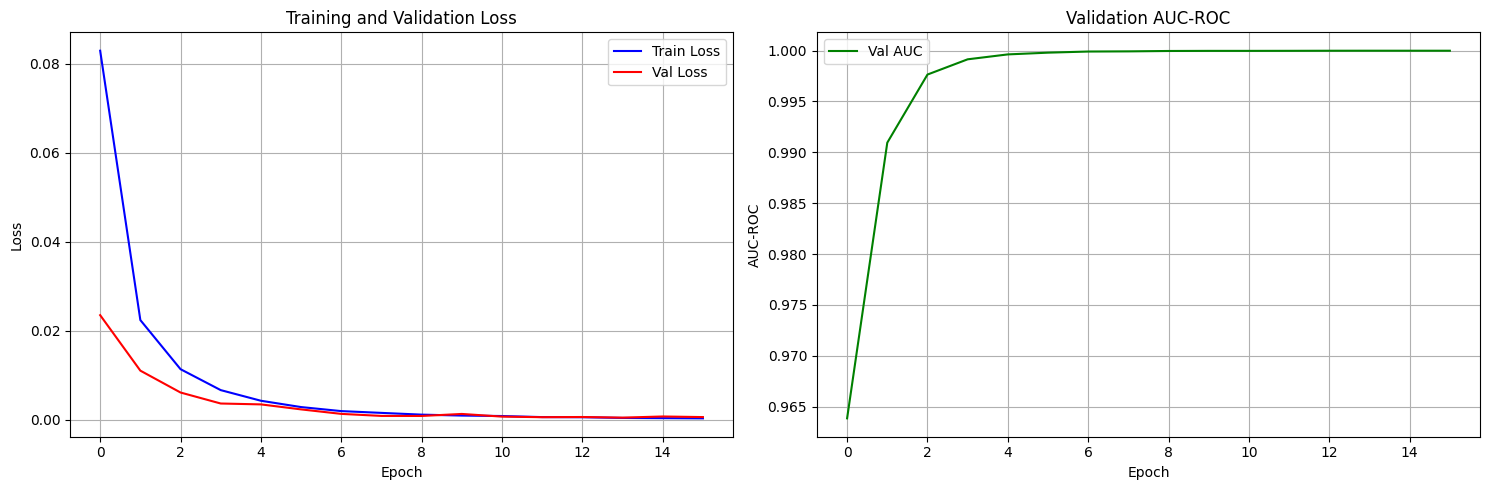

✅ Training curves saved to /kaggle/working/training_curves.png


In [17]:
# Plot training curves
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Loss curve
axes[0].plot(train_losses, label='Train Loss', color='blue')
axes[0].plot(val_losses, label='Val Loss', color='red')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training and Validation Loss')
axes[0].legend()
axes[0].grid(True)

# AUC curve
axes[1].plot(val_aucs, label='Val AUC', color='green')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('AUC-ROC')
axes[1].set_title('Validation AUC-ROC')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig('/kaggle/working/training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Training curves saved to /kaggle/working/training_curves.png")